# Mule Detection — Final Analysis
DE471 Final Project · Fan-in/Fan-out + Layering

วัดจริงจาก `Account_Summary.csv` + `Transactions.csv` + `Layering_Detection_Rate.csv`

เนื้อหา:
1. Load + Sanity check
2. Verify 5 Findings (Slide 13)
3. Apply Rule-Based Risk Score (Slide 14) + Recall / FPR / Precision
4. Threshold Trade-off Curve (Slide 15)
5. Export charts to `02_Notebooks/figures/`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = r'e:\01\dowload\power bi proeject\05_final\data'
FIG  = r'e:\01\dowload\power bi proeject\02_Notebooks\figures'
os.makedirs(FIG, exist_ok=True)

acc  = pd.read_csv(os.path.join(DATA, 'Account_Summary.csv'))
txn  = pd.read_csv(os.path.join(DATA, 'Transactions.csv'), parse_dates=['Timestamp'])
layd = pd.read_csv(os.path.join(DATA, 'Layering_Detection_Rate.csv'))

print('accounts:', acc.shape, '| transactions:', txn.shape)
print('mule accounts pct  :', round(acc['Is_Mule'].mean()*100, 2), '%')
print('mule txn pct       :', round(txn['Is_Mule'].mean()*100, 2), '%')
acc.head()

accounts: (1103, 14) | transactions: (7277, 13)
mule accounts pct  : 13.87 %
mule txn pct       : 5.32 %


,Account_ID,Account_Age_Days,Layer,Total_In_Amount,Total_Out_Amount,Outflow_Ratio_Pct,Fan_In_Count,Fan_Out_Count,Total_Transactions,Avg_Time_To_Outflow_Min,Min_Balance,Risk_Score,Risk_Level,Is_Mule
0,ACC00001,2799,Normal,22882.67,8777.37,38.4,4,4,8,0.0,23463.70,0,Normal,0
1,ACC00002,636,Normal,32981.01,30802.84,93.4,7,4,11,0.0,9007.60,30,Normal,0
2,ACC00003,282,Normal,67939.05,51555.17,75.9,12,8,20,0.0,-25779.39,30,Normal,0
3,ACC00004,3217,Normal,80363.06,31601.18,39.3,13,4,17,0.0,-18041.35,30,Normal,0
4,ACC00005,1306,Normal,29418.40,49518.99,168.3,3,8,11,0.0,-7677.19,25,Normal,0


## 1) Verify 5 Findings (Slide 13)

In [2]:
print('--- Finding 1: Hit & Run Velocity (Avg Time to Outflow, minutes) ---')
print(acc.groupby('Layer')['Avg_Time_To_Outflow_Min']
        .agg(['mean','median','count']).round(2))

print('\n--- Finding 2: Account Draining (Outflow Ratio %) ---')
print(acc.groupby('Layer')['Outflow_Ratio_Pct']
        .agg(['mean','median','count']).round(2))

print('\n--- Finding 3: Layering Detection Rate (existing system) ---')
print(layd.to_string(index=False))

--- Finding 1: Hit & Run Velocity (Avg Time to Outflow, minutes) ---
          mean  median  count
Layer                        
Layer1    3.90     3.0     20
Layer2   10.25     8.5     20
Layer3+  35.50    40.0     10
Normal    0.00     0.0    950
Victim    0.00     0.0    103

--- Finding 2: Account Draining (Outflow Ratio %) ---
           mean  median  count
Layer                         
Layer1    41.03   39.75     20
Layer2    29.36   24.70     20
Layer3+    9.26    8.95     10
Normal   133.01  101.50    950
Victim     0.00    0.00    103

--- Finding 3: Layering Detection Rate (existing system) ---
  Layer  Total_Mule_Transactions  Detection_Rate_Pct  Detected_Count  Missed_Count
 Layer1                      235                  80             188            47
 Layer2                      122                  45              55            67
Layer3+                       30                  12               4            26


In [3]:
print('--- Finding 4: PromptPay = ช่องทางหลักของม้า ---')
ch = (txn.groupby(['Channel','Is_Mule']).size().unstack(fill_value=0))
ch_pct = (ch.div(ch.sum(axis=0), axis=1) * 100).round(1)
ch_pct.columns = ['Normal_%','Mule_%']
print(ch_pct)

print('\n--- Finding 5: Mule ทำธุรกรรมกลางคืน (22:00-05:59) ---')
txn['Hour'] = txn['Timestamp'].dt.hour
txn['Night'] = txn['Hour'].between(22, 23) | txn['Hour'].between(0, 5)
night_pct = (txn.groupby('Is_Mule')['Night'].mean()*100).round(1)
print(night_pct.rename({0:'Normal_%',1:'Mule_%'}))

--- Finding 4: PromptPay = ช่องทางหลักของม้า ---
            Normal_%  Mule_%
Channel                     
ATM              9.8     9.8
Branch          20.8     4.4
Mobile_App      39.7    33.9
PromptPay       29.7    51.9

--- Finding 5: Mule ทำธุรกรรมกลางคืน (22:00-05:59) ---
Is_Mule
Normal_%     7.8
Mule_%      48.8
Name: Night, dtype: float64


## 2) Rule-Based Risk Score (Slide 14) — re-applied

In [4]:
def score_row(r):
    s = 0
    if r['Fan_In_Count'] > 4:                                        s += 30
    if r['Avg_Time_To_Outflow_Min'] > 0 and r['Avg_Time_To_Outflow_Min'] <= 15: s += 35
    if r['Outflow_Ratio_Pct'] > 95:                                  s += 25
    if r['Account_Age_Days'] < 60 and r['Fan_In_Count'] > 3:         s += 10
    return s

acc['Risk_Score_Calc'] = acc.apply(score_row, axis=1)
acc['Risk_Level_Calc'] = pd.cut(acc['Risk_Score_Calc'],
                                bins=[-1, 39, 69, 200],
                                labels=['Normal','Watch','High_Risk'])

def metrics(df, score_col, threshold):
    pred = (df[score_col] >= threshold).astype(int)
    y    = df['Is_Mule']
    tp = int(((pred==1)&(y==1)).sum())
    fp = int(((pred==1)&(y==0)).sum())
    tn = int(((pred==0)&(y==0)).sum())
    fn = int(((pred==0)&(y==1)).sum())
    recall    = tp / (tp+fn) if (tp+fn) else 0
    fpr       = fp / (fp+tn) if (fp+tn) else 0
    precision = tp / (tp+fp) if (tp+fp) else 0
    return dict(threshold=threshold, TP=tp, FP=fp, TN=tn, FN=fn,
                Recall=round(recall*100,2),
                FPR=round(fpr*100,2),
                Precision=round(precision*100,2))

print('Threshold = 70 (High_Risk)')
print(metrics(acc, 'Risk_Score_Calc', 70))
print('\nThreshold = 40 (Watch+)')
print(metrics(acc, 'Risk_Score_Calc', 40))

Threshold = 70 (High_Risk)
{'threshold': 70, 'TP': 25, 'FP': 0, 'TN': 950, 'FN': 128, 'Recall': 16.34, 'FPR': 0.0, 'Precision': 100.0}

Threshold = 40 (Watch+)
{'threshold': 40, 'TP': 38, 'FP': 393, 'TN': 557, 'FN': 115, 'Recall': 24.84, 'FPR': 41.37, 'Precision': 8.82}


## 3) Threshold Trade-off Curve (Slide 15)

 threshold  TP  FP  TN  FN  Recall    FPR  Precision
         0 153 950   0   0  100.00 100.00      13.87
         5  49 925  25 104   32.03  97.37       5.03
        10  49 925  25 104   32.03  97.37       5.03
        15  48 925  25 105   31.37  97.37       4.93
        20  48 925  25 105   31.37  97.37       4.93
        25  48 925  25 105   31.37  97.37       4.93
        30  48 800 150 105   31.37  84.21       5.66
        35  40 393 557 113   26.14  41.37       9.24
        40  38 393 557 115   24.84  41.37       8.82
        45  36 393 557 117   23.53  41.37       8.39
        50  34 393 557 119   22.22  41.37       7.96
        55  34 393 557 119   22.22  41.37       7.96
        60  34   0 950 119   22.22   0.00     100.00
        65  34   0 950 119   22.22   0.00     100.00
        70  25   0 950 128   16.34   0.00     100.00
        75  25   0 950 128   16.34   0.00     100.00
        80   0   0 950 153    0.00   0.00       0.00
        85   0   0 950 153    0.00   0.00     

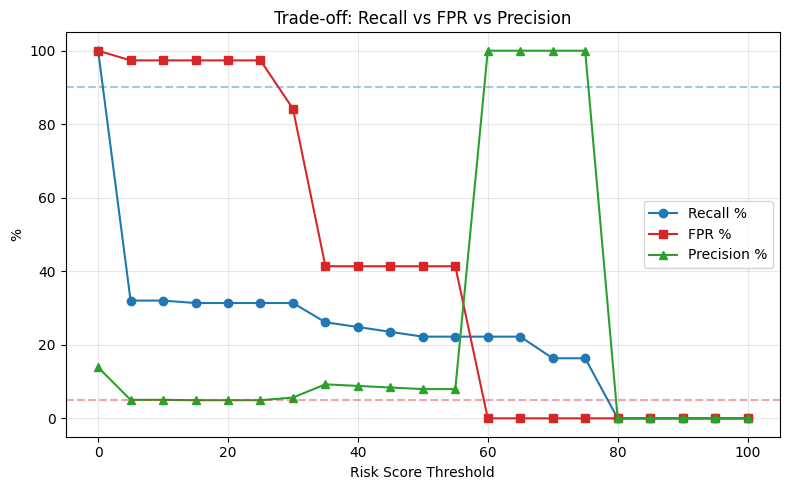


Thresholds meeting target (Recall>=90 AND FPR<=5):
  (none — relax target or improve rules)


In [5]:
rows = [metrics(acc, 'Risk_Score_Calc', t) for t in range(0, 101, 5)]
tr = pd.DataFrame(rows)
print(tr.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(tr['threshold'], tr['Recall'],    marker='o', color='#1f77b4', label='Recall %')
ax.plot(tr['threshold'], tr['FPR'],       marker='s', color='#d62728', label='FPR %')
ax.plot(tr['threshold'], tr['Precision'], marker='^', color='#2ca02c', label='Precision %')
ax.axhline(90, ls='--', color='#1f77b4', alpha=.4)
ax.axhline(5,  ls='--', color='#d62728', alpha=.4)
ax.set_xlabel('Risk Score Threshold')
ax.set_ylabel('%')
ax.set_title('Trade-off: Recall vs FPR vs Precision')
ax.legend()
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG, '05_tradeoff_curve.png'), dpi=140)
plt.show()

good = tr[(tr['Recall']>=90) & (tr['FPR']<=5)]
print('\nThresholds meeting target (Recall>=90 AND FPR<=5):')
print(good if len(good) else '  (none — relax target or improve rules)')

## 4) Charts สำหรับ slide deck

C:\Users\UsEr\AppData\Local\Temp\ipykernel_8616\2201562039.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ORDER, patch_artist=True)


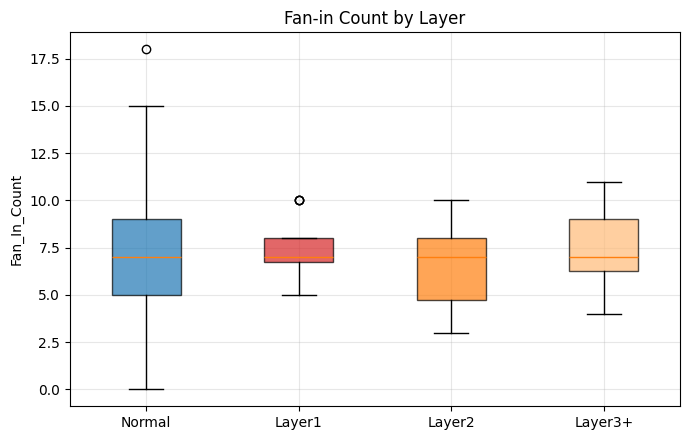

C:\Users\UsEr\AppData\Local\Temp\ipykernel_8616\2201562039.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ORDER, patch_artist=True)


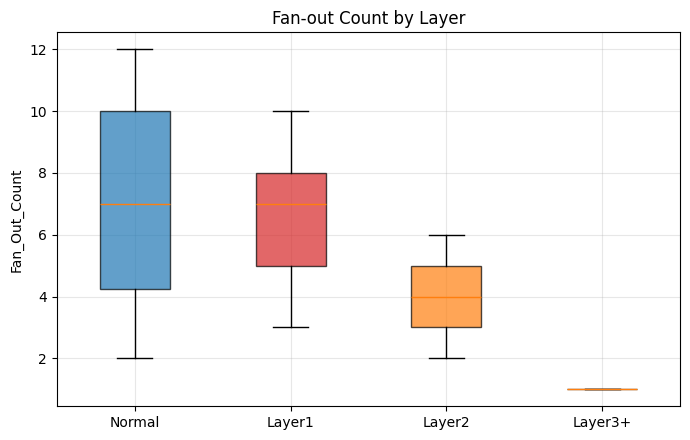

C:\Users\UsEr\AppData\Local\Temp\ipykernel_8616\2201562039.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ORDER, patch_artist=True)


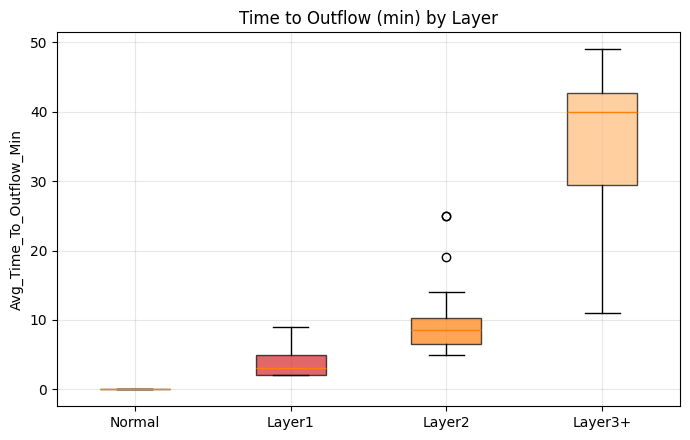

C:\Users\UsEr\AppData\Local\Temp\ipykernel_8616\2201562039.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ORDER, patch_artist=True)


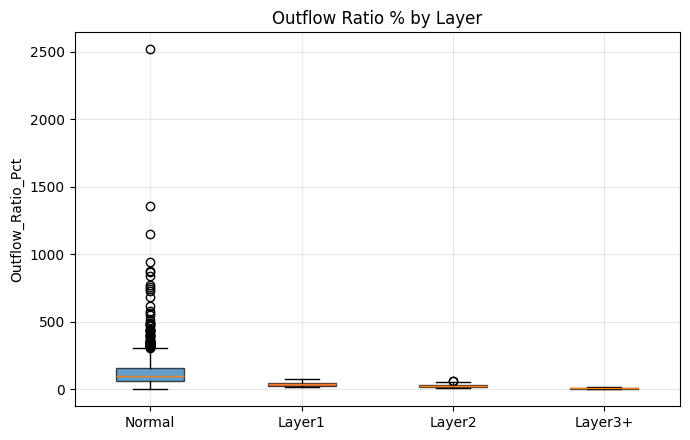

In [6]:
PALETTE = {'Normal':'#1f77b4','Victim':'#7f7f7f','Layer1':'#d62728',
           'Layer2':'#ff7f0e','Layer3+':'#ffbb78'}
ORDER = ['Normal','Layer1','Layer2','Layer3+']

def boxplot_by_layer(col, fname, title):
    sub = acc[acc['Layer'].isin(ORDER)]
    data = [sub.loc[sub['Layer']==L, col].values for L in ORDER]
    fig, ax = plt.subplots(figsize=(7,4.5))
    bp = ax.boxplot(data, labels=ORDER, patch_artist=True)
    for patch, L in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[L]); patch.set_alpha(.7)
    ax.set_title(title); ax.set_ylabel(col); ax.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(os.path.join(FIG, fname), dpi=140); plt.show()

boxplot_by_layer('Fan_In_Count',            '01_fanin_box.png',  'Fan-in Count by Layer')
boxplot_by_layer('Fan_Out_Count',           '02_fanout_box.png', 'Fan-out Count by Layer')
boxplot_by_layer('Avg_Time_To_Outflow_Min', '03_time_box.png',   'Time to Outflow (min) by Layer')
boxplot_by_layer('Outflow_Ratio_Pct',       '04_outflow_box.png','Outflow Ratio % by Layer')

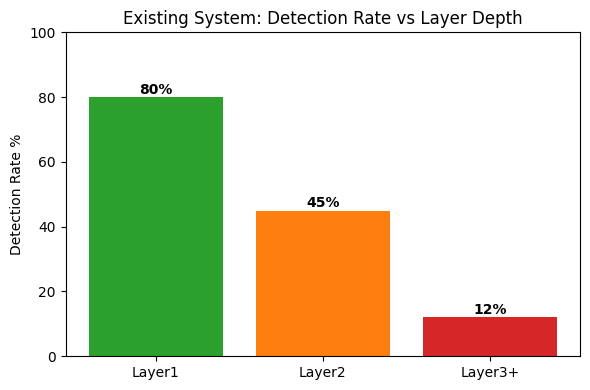

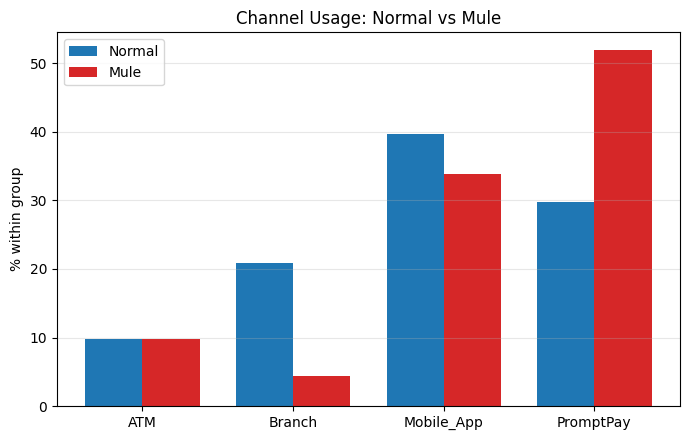

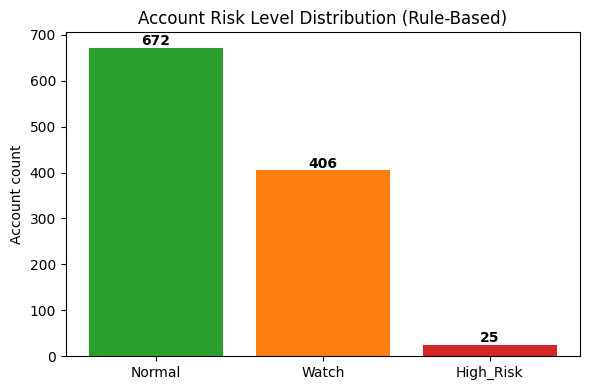

In [7]:
# Layering Detection Rate bar
fig, ax = plt.subplots(figsize=(6,4))
colors = ['#2ca02c' if v>=70 else '#ff7f0e' if v>=40 else '#d62728'
          for v in layd['Detection_Rate_Pct']]
ax.bar(layd['Layer'], layd['Detection_Rate_Pct'], color=colors)
for i,v in enumerate(layd['Detection_Rate_Pct']):
    ax.text(i, v+1, f'{v}%', ha='center', fontweight='bold')
ax.set_ylim(0,100); ax.set_ylabel('Detection Rate %')
ax.set_title('Existing System: Detection Rate vs Layer Depth')
fig.tight_layout(); fig.savefig(os.path.join(FIG, '06_layer_detection.png'), dpi=140); plt.show()

# Channel Usage Normal vs Mule (% within group)
ch_p = ch_pct.reset_index()
x = np.arange(len(ch_p)); w = 0.38
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(x-w/2, ch_p['Normal_%'], w, label='Normal', color='#1f77b4')
ax.bar(x+w/2, ch_p['Mule_%'],   w, label='Mule',   color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(ch_p['Channel'])
ax.set_ylabel('% within group'); ax.set_title('Channel Usage: Normal vs Mule')
ax.legend(); ax.grid(alpha=.3, axis='y')
fig.tight_layout(); fig.savefig(os.path.join(FIG, '07_channel.png'), dpi=140); plt.show()

# Risk Level Summary
rl = acc['Risk_Level_Calc'].value_counts().reindex(['Normal','Watch','High_Risk'])
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(rl.index, rl.values, color=['#2ca02c','#ff7f0e','#d62728'])
for i,v in enumerate(rl.values):
    ax.text(i, v+5, str(int(v)), ha='center', fontweight='bold')
ax.set_title('Account Risk Level Distribution (Rule-Based)')
ax.set_ylabel('Account count')
fig.tight_layout(); fig.savefig(os.path.join(FIG, '08_risk_level.png'), dpi=140); plt.show()

## 5) Top 10 Risky Accounts

In [8]:
cols = ['Account_ID','Layer','Account_Age_Days','Fan_In_Count','Fan_Out_Count',
        'Outflow_Ratio_Pct','Avg_Time_To_Outflow_Min','Risk_Score_Calc',
        'Risk_Level_Calc','Is_Mule']
top10 = acc.sort_values('Risk_Score_Calc', ascending=False).head(10)[cols]
print(top10.to_string(index=False))

 Account_ID  Layer  Account_Age_Days  Fan_In_Count  Fan_Out_Count  Outflow_Ratio_Pct  Avg_Time_To_Outflow_Min  Risk_Score_Calc Risk_Level_Calc  Is_Mule
MULE_L1_001 Layer1                51             6              3               38.3                      2.0               75       High_Risk        1
MULE_L1_002 Layer1                45            10              7               21.4                      2.0               75       High_Risk        1
MULE_L1_003 Layer1                37             8              8               45.2                      9.0               75       High_Risk        1
MULE_L1_004 Layer1                25             7              7               53.3                      2.0               75       High_Risk        1
MULE_L1_005 Layer1                 9             5              5               43.5                      3.0               75       High_Risk        1
MULE_L1_006 Layer1                21            10              9               32.3    